# Linguistic Profiling of a Short Story with spaCy

## Project Overview

This project builds a complete text-preprocessing and linguistic-annotation pipeline for Ambrose Bierce's short story *An Occurrence at Owl Creek Bridge* (1890). It uses spaCy and NLTK to:

- Clean a raw Project Gutenberg file into analysis-ready text.
- Tokenize, sentence-split, and tag the text with part-of-speech, dependency, lemma, and morphology labels.
- Compare stemming and lemmatization as vocabulary-normalization strategies.
- Extract named entities and review where the pretrained model gets them wrong.
- Use rule-based matching (`Matcher` and `PhraseMatcher`) to locate phrases and track themes across the story.

The final analysis uses verb-tense annotations to detect a narrative device in the story: a shift from past to present tense in the closing scene.

**Tools:** Python, spaCy (`en_core_web_sm`), NLTK stemmers, pandas, matplotlib, seaborn.

## Objective

Show how standard NLP preprocessing steps (tokenization, normalization, stop-word filtering, tagging, and rule-based matching) turn raw literary text into structured data, and use those annotations to answer concrete questions about the story.

## Dataset

| Property | Value |
|---|---|
| Text | *An Occurrence at Owl Creek Bridge*, Ambrose Bierce (1890) |
| Source | [Project Gutenberg eBook #375](https://www.gutenberg.org/ebooks/375) |
| File | `data/owlcreek.txt` (UTF-8, about 22 KB) |
| License | Public domain in the United States. Project Gutenberg's license header is kept in the raw file and removed during preprocessing. |

The story has three numbered parts: **I** (the hanging is prepared), **II** (a flashback explaining how Peyton Farquhar got there), and **III** (his apparent escape).

## Setup and Imports

In [ ]:
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import spacy
from nltk.stem import PorterStemmer, SnowballStemmer
from spacy.matcher import Matcher, PhraseMatcher

DATA_PATH = Path("data") / "owlcreek.txt"
SPACY_MODEL = "en_core_web_sm"

sns.set_theme(style="whitegrid", context="notebook")
PART_COLORS = {"I": "#2a78d6", "II": "#eb6834", "III": "#1baf7a"}
pd.set_option("display.max_colwidth", 120)

try:
    nlp = spacy.load(SPACY_MODEL)
except OSError as error:
    raise OSError(
        f"spaCy model '{SPACY_MODEL}' is not installed. Run: python -m spacy download {SPACY_MODEL}"
    ) from error

## Data Preparation

The raw file needs three fixes before analysis:

1. **Remove the Gutenberg license header.** If it stays in, license sentences get counted as part of the story.
2. **Split the text into its three parts** using the Roman-numeral headings.
3. **Unwrap hard line breaks.** Gutenberg wraps lines at about 70 characters. spaCy turns each line break into a `SPACE` token, which inflates token counts and breaks phrase matching across lines. Paragraph breaks are kept.

In [ ]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Expected the story at {DATA_PATH.resolve()}. See the Dataset section.")

raw_text = DATA_PATH.read_text(encoding="utf-8")
START_MARKER = "*** START OF THE PROJECT GUTENBERG EBOOK AN OCCURRENCE AT OWL CREEK BRIDGE ***"
story_body = raw_text.split(START_MARKER, maxsplit=1)[1]


def unwrap_lines(text):
    """Join hard-wrapped lines inside paragraphs while keeping paragraph breaks."""
    paragraphs = re.split(r"\n\s*\n", text.strip())
    return "\n\n".join(re.sub(r"\s*\n\s*", " ", p).strip() for p in paragraphs if p.strip())


# Part headings are standalone Roman numerals: I, II, III
section_chunks = re.split(r"\n\s*(I{1,3})\s*\n", story_body)
# re.split returns [title, "I", text, "II", text, "III", text]
story_parts = {
    section_chunks[i]: unwrap_lines(section_chunks[i + 1])
    for i in range(1, len(section_chunks), 2)
}
print({part: f"{len(text):,} characters" for part, text in story_parts.items()})

{'I': '6,000 characters', 'II': '2,740 characters', 'III': '12,332 characters'}


In [ ]:
raw_story_doc = nlp(story_body)
part_docs = {part: nlp(text) for part, text in story_parts.items()}

clean_token_total = sum(len(doc) for doc in part_docs.values())
pd.DataFrame({
    "Tokens": [len(raw_story_doc), clean_token_total],
    "SPACE tokens": [sum(t.is_space for t in raw_story_doc),
                     sum(t.is_space for doc in part_docs.values() for t in doc)],
}, index=["Raw story text", "Cleaned parts"])

,Tokens,SPACE tokens
Raw story text,4683,326
Cleaned parts,4373,34


## Exploratory Analysis

### Size and structure of each part

In [ ]:
def part_summary(doc):
    words = [t for t in doc if t.is_alpha]
    sentences = list(doc.sents)
    return {
        "Tokens": len(doc),
        "Words": len(words),
        "Sentences": len(sentences),
        "Words per sentence": round(len(words) / len(sentences), 1),
        "Type-token ratio": round(len({t.lower_ for t in words}) / len(words), 3),
    }


pd.DataFrame({part: part_summary(doc) for part, doc in part_docs.items()}).T

,Tokens,Words,Sentences,Words per sentence,Type-token ratio
I,1228.0,1068.0,55.0,19.4,0.460
II,576.0,483.0,23.0,21.0,0.532
III,2569.0,2211.0,120.0,18.4,0.374


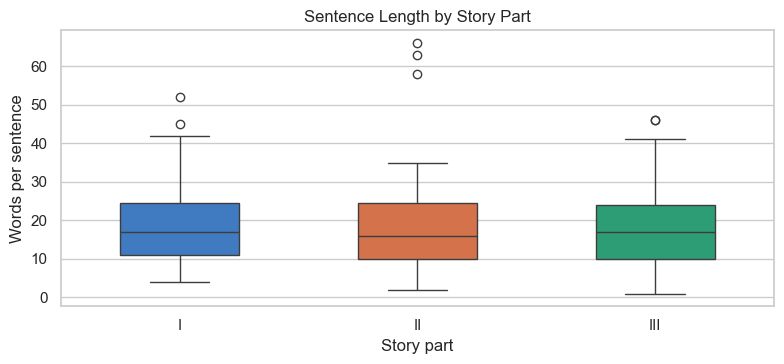

In [ ]:
sentence_lengths = pd.DataFrame([
    {"Part": part, "Words": sum(t.is_alpha for t in sentence)}
    for part, doc in part_docs.items()
    for sentence in doc.sents
])

fig, ax = plt.subplots(figsize=(8, 3.8))
sns.boxplot(data=sentence_lengths, x="Part", y="Words", hue="Part",
            palette=PART_COLORS, width=0.5, legend=False, ax=ax)
ax.set_title("Sentence Length by Story Part")
ax.set_xlabel("Story part")
ax.set_ylabel("Words per sentence")
plt.tight_layout()
plt.show()

### Token-level annotations

Each token carries several linguistic layers. The opening sentence of Part I shows them side by side.

In [ ]:
opening_sentence = next(part_docs["I"].sents)
pd.DataFrame([
    {
        "Token": t.text,
        "POS": t.pos_,
        "Fine tag": t.tag_,
        "Dependency": t.dep_,
        "Head": t.head.text,
        "Lemma": t.lemma_,
        "Morphology": str(t.morph),
    }
    for t in opening_sentence
])

,Token,POS,Fine tag,Dependency,Head,Lemma,Morphology
0,A,DET,DT,det,man,a,Definite=Ind|PronType=Art
1,man,NOUN,NN,nsubj,stood,man,Number=Sing
2,stood,VERB,VBD,ROOT,stood,stand,Tense=Past|VerbForm=Fin
3,upon,SCONJ,IN,prep,stood,upon,
4,a,DET,DT,det,bridge,a,Definite=Ind|PronType=Art
5,railroad,NOUN,NN,compound,bridge,railroad,Number=Sing
6,bridge,NOUN,NN,pobj,upon,bridge,Number=Sing
7,in,ADP,IN,prep,bridge,in,
8,northern,ADJ,JJ,amod,Alabama,northern,Degree=Pos
9,Alabama,PROPN,NNP,pobj,in,Alabama,Number=Sing


## Text Normalization

### Stemming vs. lemmatization

Both techniques collapse inflected forms so that, for example, *swimming* and *swims* can be counted together. They take different approaches:

- **Stemmers** (Porter, Snowball) strip suffixes with fixed rules and can produce non-words.
- **Lemmatization** (spaCy) uses the part-of-speech tag to return a dictionary form.

The table measures how much each method shrinks the story's vocabulary.

In [ ]:
porter = PorterStemmer()
snowball = SnowballStemmer("english")

story_words = [t for doc in part_docs.values() for t in doc if t.is_alpha]

vocabulary_sizes = {
    "Lowercased words": len({t.lower_ for t in story_words}),
    "Porter stems": len({porter.stem(t.lower_) for t in story_words}),
    "Snowball stems": len({snowball.stem(t.lower_) for t in story_words}),
    "spaCy lemmas": len({t.lemma_.lower() for t in story_words}),
}
vocabulary_table = pd.DataFrame({"Unique types": vocabulary_sizes})
vocabulary_table["Reduction vs. raw"] = (
    1 - vocabulary_table["Unique types"] / vocabulary_sizes["Lowercased words"]
).map("{:.1%}".format)
vocabulary_table

,Unique types,Reduction vs. raw
Lowercased words,1257,0.0%
Porter stems,1121,10.8%
Snowball stems,1112,11.5%
spaCy lemmas,1117,11.1%


The examples below show where the methods disagree. Stemmers produce truncated forms (`suddenli`), while the lemmatizer handles irregular forms (`saw` → `see`) that suffix rules cannot.

In [ ]:
example_words = ["swimming", "suddenly", "saw", "was", "feet", "eyes", "terrible",
                 "gently", "hanged", "children"]
first_token = {}
for t in story_words:
    first_token.setdefault(t.lower_, t)

pd.DataFrame([
    {
        "Word": word,
        "spaCy POS": first_token[word].pos_,
        "Porter": porter.stem(word),
        "Snowball": snowball.stem(word),
        "spaCy lemma": first_token[word].lemma_,
    }
    for word in example_words if word in first_token
])

,Word,spaCy POS,Porter,Snowball,spaCy lemma
0,swimming,VERB,swim,swim,swim
1,suddenly,ADV,suddenli,sudden,suddenly
2,saw,VERB,saw,saw,see
3,was,AUX,wa,was,be
4,feet,NOUN,feet,feet,foot
5,eyes,NOUN,eye,eye,eye
6,terrible,ADJ,terribl,terribl,terrible
7,gently,ADV,gentli,gentl,gently
8,hanged,VERB,hang,hang,hang
9,children,NOUN,children,children,child


### Stop words and content vocabulary

spaCy's default English stop list removes function words such as *the*, *of*, and *was*. After removing stop words and punctuation, the most frequent lemmas reflect the story's main subjects.

spaCy stop list size: 326
Share of story words that are stop words: 55.6%


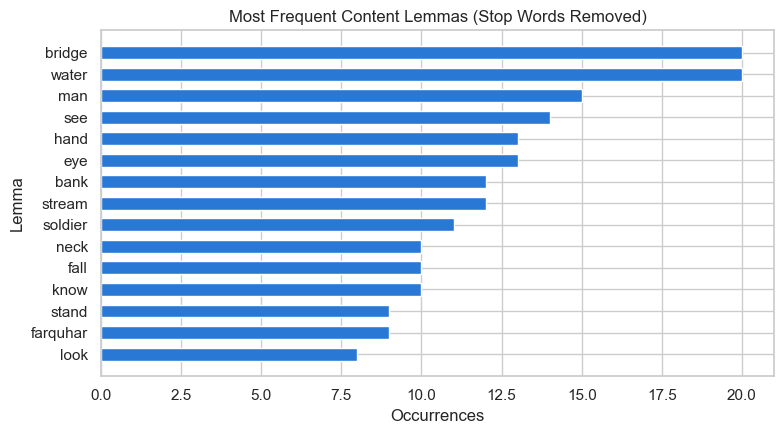

In [ ]:
stop_word_share = sum(t.is_stop for t in story_words) / len(story_words)
print(f"spaCy stop list size: {len(nlp.Defaults.stop_words)}")
print(f"Share of story words that are stop words: {stop_word_share:.1%}")

content_lemmas = Counter(
    t.lemma_.lower() for t in story_words if not t.is_stop and t.pos_ in {"NOUN", "VERB", "ADJ", "PROPN"}
)
top_lemmas = pd.DataFrame(content_lemmas.most_common(15), columns=["Lemma", "Count"])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top_lemmas["Lemma"][::-1], top_lemmas["Count"][::-1], color="#2a78d6", height=0.6)
ax.set_title("Most Frequent Content Lemmas (Stop Words Removed)")
ax.set_xlabel("Occurrences")
ax.set_ylabel("Lemma")
plt.tight_layout()
plt.show()

## Named Entity Recognition

The small pretrained pipeline was trained on modern web and news text, not 19th-century fiction. Listing every person and place it finds shows both what it catches and where it makes mistakes.

In [ ]:
entity_rows = [
    {"Part": part, "Entity": ent.text, "Label": ent.label_}
    for part, doc in part_docs.items()
    for ent in doc.ents
]
entities = pd.DataFrame(entity_rows)

print("Entity counts by label:")
print(entities["Label"].value_counts().to_string())

(entities[entities["Label"].isin(["PERSON", "GPE", "LOC", "ORG", "NORP"])]
 .groupby(["Label", "Entity"]).size().rename("Mentions").reset_index()
 .sort_values(["Label", "Mentions"], ascending=[True, False]))

Entity counts by label:
Label
CARDINAL       19
GPE             9
PERSON          7
QUANTITY        6
TIME            5
DATE            4
ORDINAL         4
ORG             3
NORP            2
LOC             1
WORK_OF_ART     1


,Label,Entity,Mentions
1,GPE,Farquhar,4
0,GPE,Alabama,2
2,GPE,fort,2
3,GPE,veranda,1
4,LOC,South,1
5,NORP,AEolian,1
6,NORP,Southern,1
8,ORG,the Owl Creek bridge,2
7,ORG,DIMINUENDO,1
12,PERSON,Peyton Farquhar,3


## Rule-Based Matching

### Token patterns with `Matcher`

`Matcher` finds sequences of tokens by their attributes instead of exact strings. Matching on the **lemma** `swim` followed by an adverb finds both uses of *swimming vigorously*, along with any other form of *swim* followed by an adverb. This works only because the line breaks were removed earlier. Otherwise the pattern would need an extra slot for a `SPACE` token.

In [ ]:
matcher = Matcher(nlp.vocab)
matcher.add("SWIM_ADVERB", [[{"LEMMA": "swim"}, {"POS": "ADV"}]])

swim_matches = [
    {"Part": part, "Match": doc[start:end].text, "Sentence": doc[start:end].sent.text}
    for part, doc in part_docs.items()
    for _, start, end in matcher(doc)
]
pd.DataFrame(swim_matches)

,Part,Match,Sentence
0,I,swimming vigorously,"By diving I could evade the bullets and, swimming vigorously, reach the bank, take to the woods and get away home."
1,III,swimming vigorously,The hunted man saw all this over his shoulder; he was now swimming vigorously with the current.


### Theme tracking with `PhraseMatcher`

`PhraseMatcher` searches efficiently for long term lists. Two small hand-built lexicons, one for **water/river** words and one for **home/family** words, show how the story's setting moves between the river and Farquhar's home. Matching is case-insensitive (`attr="LOWER"`), and the lists include plural forms explicitly.

In [ ]:
THEME_LEXICONS = {
    "Water / river": ["water", "waters", "stream", "river", "current", "bank", "banks", "creek",
                      "swim", "swimming", "surface", "bottom", "drown", "drowned", "gravel"],
    "Home / family": ["home", "wife", "children", "gate", "veranda", "house", "plantation",
                      "family", "door"],
}
phrase_matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
for theme, terms in THEME_LEXICONS.items():
    phrase_matcher.add(theme, [nlp.make_doc(term) for term in terms])

theme_counts = pd.DataFrame({
    part: Counter(nlp.vocab.strings[match_id] for match_id, _, _ in phrase_matcher(doc))
    for part, doc in part_docs.items()
}).fillna(0).astype(int).T

# Normalize by part length so the parts can be compared fairly
words_per_part = pd.Series({part: sum(t.is_alpha for t in doc) for part, doc in part_docs.items()})
theme_rates = theme_counts.div(words_per_part, axis=0).mul(1000).round(1)
theme_rates.columns = [f"{theme} (per 1,000 words)" for theme in theme_rates.columns]
pd.concat([theme_counts, theme_rates], axis=1)

,Water / river,Home / family,"Water / river (per 1,000 words)","Home / family (per 1,000 words)"
I,16,5,15.0,4.7
II,7,4,14.5,8.3
III,39,7,17.6,3.2


## Narrative Analysis: Detecting a Tense Shift

Part III describes Farquhar's escape in the past tense. In the final paragraphs, Bierce switches to the present tense ("He stands at the gate of his own home") just before revealing that the escape was imagined.

spaCy's morphological features include `Tense` for finite verbs. Tracking the share of present-tense finite verbs over a rolling window of sentences should make this shift visible. Dialogue and narrator commentary also use the present tense, so isolated spikes are expected. The question is whether the ending shows a sustained jump.

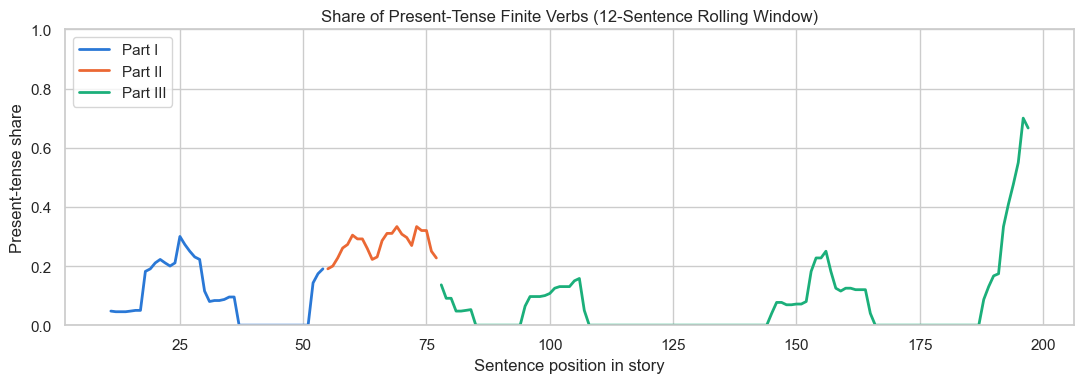

In [ ]:
def finite_verb_tenses(sentence):
    return [
        t.morph.get("Tense")[0]
        for t in sentence
        if t.pos_ in {"VERB", "AUX"} and "Fin" in t.morph.get("VerbForm") and t.morph.get("Tense")
    ]


sentence_rows = []
for part, doc in part_docs.items():
    for sentence in doc.sents:
        tenses = finite_verb_tenses(sentence)
        sentence_rows.append({
            "Part": part,
            "present_verbs": tenses.count("Pres"),
            "finite_verbs": len(tenses),
            "text": sentence.text,
        })

tense_by_sentence = pd.DataFrame(sentence_rows)
tense_by_sentence["sentence_index"] = range(len(tense_by_sentence))

WINDOW = 12
rolling = tense_by_sentence[["present_verbs", "finite_verbs"]].rolling(WINDOW, min_periods=WINDOW).sum()
tense_by_sentence["rolling_present_share"] = rolling["present_verbs"] / rolling["finite_verbs"]

fig, ax = plt.subplots(figsize=(11, 4))
for part, color in PART_COLORS.items():
    part_rows = tense_by_sentence[tense_by_sentence["Part"] == part]
    ax.plot(part_rows["sentence_index"], part_rows["rolling_present_share"],
            color=color, linewidth=2, label=f"Part {part}")
ax.set_title(f"Share of Present-Tense Finite Verbs ({WINDOW}-Sentence Rolling Window)")
ax.set_xlabel("Sentence position in story")
ax.set_ylabel("Present-tense share")
ax.set_ylim(0, 1)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
part_three = tense_by_sentence[tense_by_sentence["Part"] == "III"]
final_scene = part_three.tail(15)
rest_of_part_three = part_three.iloc[:-15]

pd.DataFrame({
    "Present-tense share": [
        rest_of_part_three["present_verbs"].sum() / rest_of_part_three["finite_verbs"].sum(),
        final_scene["present_verbs"].sum() / final_scene["finite_verbs"].sum(),
    ],
    "Sentences": [len(rest_of_part_three), len(final_scene)],
}, index=["Part III, before final scene", "Part III, last 15 sentences"]).round(3)

,Present-tense share,Sentences
"Part III, before final scene",0.038,105
"Part III, last 15 sentences",0.519,15


In [ ]:
# Sentences in the final scene with present-tense verbs
with pd.option_context("display.max_colwidth", None):
    display(final_scene.loc[final_scene["present_verbs"] > 0, ["present_verbs", "finite_verbs", "text"]].head(8))

,present_verbs,finite_verbs,text
188,2,3,"Doubtless, despite his suffering, he had fallen asleep while walking, for now he sees another scene—perhaps he has merely recovered from a delirium."
189,1,1,He stands at the gate of his own home.
190,1,2,"All is as he left it, and all bright and beautiful in the morning sunshine."
192,4,4,"As he pushes open the gate and passes up the wide white walk, he sees a flutter of female garments; his wife, looking fresh and cool and sweet, steps down from the veranda to meet him."
193,1,1,"At the bottom of the steps she stands waiting, with a smile of ineffable joy, an attitude of matchless grace and dignity."
194,1,1,"Ah, how beautiful she is!"
195,1,1,He springs forwards with extended arms.
196,3,3,As he is about to clasp her he feels a stunning blow upon the back of the neck; a blinding white light blazes all about him with a sound like the shock of a cannon—then all is darkness and silence!\n\n


## Key Findings

- **Cleaning matters for counting.** Removing the license header and unwrapping hard line breaks cut the token count from 4,683 to 4,373. Most of the difference is `SPACE` tokens (326 down to 34). Without this step, sentence counts include license text, and phrase patterns fail when a phrase is split across lines.
- **The three normalization methods shrink the vocabulary by similar amounts** (11–12%, from 1,257 word types), but their output quality differs. Porter produces non-words (`suddenli`, `wa`). Only the lemmatizer handles irregular forms (`saw` → `see`, `feet` → `foot`, `children` → `child`).
- **Stop words make up 55.6% of the story's words.** After removing them, the top content lemmas (*bridge*, *water*, *man*, *see*, *hand*, *eye*) reflect the story's setting and its focus on physical perception.
- **The small pretrained NER model struggles with 19th-century fiction.** It labels *Farquhar* as a place (GPE) in 4 of 9 mentions. It also tags *fort* and *veranda* as places, *Aim* (a soldier's command) and *Niagara* as people, and *DIMINUENDO* as an organization.
- **Lemma-based matching generalizes better than exact strings.** A two-token pattern (lemma `swim` + adverb) found both *swimming vigorously* passages without needing a pattern slot for line breaks.
- **Theme rates follow the story's settings.** Part III has the highest rate of water/river terms (17.6 per 1,000 words), which matches the drawn-out river escape. Part II, the flashback set at Farquhar's plantation, has the highest rate of home/family terms (8.3 per 1,000 words).
- **Morphological tags detect the tense shift.** In Part III, present-tense verbs make up 3.8% of finite verbs before the final scene and 51.9% in the last 15 sentences ("He stands at the gate of his own home"). The rolling chart shows this as the largest sustained spike in the story. Smaller bumps in Parts I and II come from dialogue and narrator commentary.

## Limitations

- `en_core_web_sm` is the smallest English pipeline. Larger models (`en_core_web_lg`, `en_core_web_trf`) would likely fix some entity errors but are slower and much larger to download.
- The theme lexicons are hand-built and small. Their counts show broad trends, not exact measurements.

